In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

2023-04-25 09:40:27.194026: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-25 09:40:28.595891: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/xmatyas/miniconda3/envs/tf_gpu/lib/
2023-04-25 09:40:28.595945: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/xmatyas/miniconda3/envs/tf_gpu/lib/
2023-04-25 09:40:28.595950: W tensorflow/com

Num GPUs Available:  1
1 Physical GPUs, 1 Logical GPUs


2023-04-25 09:40:29.883056: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-25 09:40:29.883199: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-25 09:40:29.883293: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-25 09:40:30.606350: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-25 09:40:30.607079: I tensorflow/compiler/xla/stream_executo

In [3]:
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

for dirname, _, filenames in os.walk('input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

input/t10k-labels.idx1-ubyte
input/emnist-balanced-mapping.txt
input/emnist-byclass-train.csv
input/emnist-balanced-test.csv
input/emnist-byclass-test.csv
input/emnist-digits-test.csv
input/t10k-images.idx3-ubyte
input/emnist-balanced-train.csv
input/emnist-byclass-mapping.txt
input/emnist-digits-mapping.txt
input/emnist-digits-train.csv
input/emnist-mnist-mapping.txt
input/emnist-bymerge-test.csv
input/emnist-bymerge-mapping.txt
input/emnist-letters-train.csv
input/train-labels.idx1-ubyte
input/emnist-mnist-test.csv
input/emnist-letters-mapping.txt
input/train-images.idx3-ubyte
input/emnist-bymerge-train.csv
input/emnist-mnist-train.csv
input/emnist-letters-test.csv
input/train-labels-idx1-ubyte/train-labels-idx1-ubyte
input/emnist_source_files/emnist-letters-train-images-idx3-ubyte
input/emnist_source_files/emnist-mnist-train-images-idx3-ubyte
input/emnist_source_files/emnist-bymerge-train-labels-idx1-ubyte
input/emnist_source_files/emnist-mnist-test-labels-idx1-ubyte
input/emnist_so

In [4]:
testing_letter = pd.read_csv('input/emnist-letters-test.csv')
training_letter = pd.read_csv('input/emnist-letters-train.csv')
class_map = 'ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'
print(testing_letter.shape)
print(training_letter.shape)
print(len(class_map))

(14799, 785)
(88799, 785)
37


In [5]:
#training_letters
y1 = np.array(training_letter.iloc[:,0].values)
x1 = np.array(training_letter.iloc[:,1:].values)
#testing_letters
y2 = np.array(testing_letter.iloc[:,0].values)
x2 = np.array(testing_letter.iloc[:,1:].values)
print(y1.shape)
print(x1.shape)

(88799,)
(88799, 784)


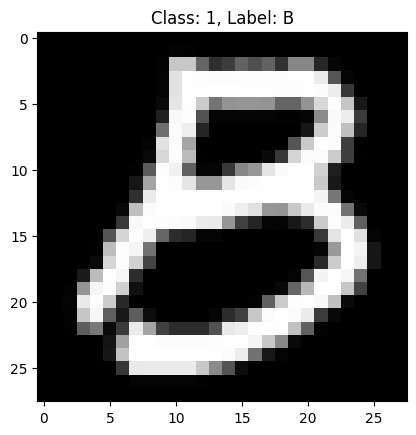

In [6]:
def show_img(data, row_num):
    img_flip = np.transpose(data.values[row_num,1:].reshape(28, 28), axes=[1,0]) # img_size * img_size arrays
    plt.title('Class: ' + str(data.values[row_num,0]-1) + ', Label: ' + str(class_map[data.values[row_num,0]-1]))
    plt.imshow(img_flip, cmap='Greys_r')

show_img(testing_letter, 1000)

In [ ]:
import tensorflow as tf

# Normalise and reshape data
train_images = x1 / 255.0
test_images = x2 / 255.0

train_images_number = train_images.shape[0]
train_images_height = 28
train_images_width = 28
train_images_size = train_images_height*train_images_width

train_images = train_images.reshape(train_images_number, train_images_height, train_images_width, 1)

test_images_number = test_images.shape[0]
test_images_height = 28
test_images_width = 28
test_images_size = test_images_height*test_images_width

test_images = test_images.reshape(test_images_number, test_images_height, test_images_width, 1)


In [ ]:
# Transform labels
number_of_classes = 37

y1 = tf.keras.utils.to_categorical(y1, number_of_classes)
y2 = tf.keras.utils.to_categorical(y2, number_of_classes)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

train_x,test_x,train_y,test_y = train_test_split(train_images,y1,test_size=0.2,random_state = 42)



model = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32,3,input_shape=(28,28,1),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Conv2D(64,3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Conv2D(128,3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    #################################################
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    #tf.keras.layers.Dense(512,activation='relu'),
    #tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(number_of_classes, activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=tf.keras.metrics.CategoricalAccuracy())

In [ ]:
es = EarlyStopping(monitor='val_categorical_accuracy', mode='max', verbose=1, patience=175)
mc = ModelCheckpoint('advanced2_emnist_model.h5', monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True, patience=175)
history = model.fit(train_x, train_y, batch_size=2048 , epochs=100, validation_split = 0.20 , callbacks=[es,mc])

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('advanced2_emnist_model.h5')
model.evaluate(test_x, test_y, verbose=2)

probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])
probability_model(test_x[:5])

In [ ]:
conf_mat = confusion_matrix(y_true = np.argmax(test_y, axis=1), y_pred = np.argmax(model.predict(test_x), axis=1))
plt.imshow(conf_mat, cmap = 'gray', vmin = 0, vmax = 255)
plt.show()

#import ipympl
#%matplotlib widget

In [ ]:
import random

def show_predicted_images(images, title_texts, predicted_labels):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1
    for x in zip(images, title_texts, predicted_labels):
        image = x[0]        
        title_text = np.argmax(x[1])
        predicted_label = x[2]
        plt.subplot(rows, cols, index)
        image_flip = np.transpose(image.reshape(28, 28), axes=[1,0]) # img_size * img_size arrays    
        plt.imshow(image_flip, cmap='Greys_r')
        if (title_text != ''):
            if (title_text == predicted_label):
                plt.title("Label : " + str(class_map[title_text-1]) + "  Predicted : " + str(class_map[predicted_label-1]), fontsize = 15);
            else:
                plt.title("Label : " + str(class_map[title_text-1]) + "  Predicted : " + str(class_map[predicted_label-1]), fontsize = 15, color = 'red');
        index += 1

random_image_index = []
for i in range(0, 20):
    r = random.randint(1, len(test_x))
    random_image_index.append(r)
if len(random_image_index) > 0:
    random_x_val = np.array([test_x[index] for index in random_image_index])
    random_y_val = np.array([test_y[index] for index in random_image_index])

predicted_labels = model.predict(random_x_val)
predicted_labels = np.argmax(predicted_labels, 1)
show_predicted_images(random_x_val,random_y_val,predicted_labels)

In [ ]:
import random

def show_wrongly_predicted_images(images, title_labels, predicted_labels, r_num):
    wrong_predictions = []
    for x in zip(images, title_labels, predicted_labels):
        image = x[0]
        title_label = np.argmax(x[1])
        predicted_label = x[2]
        #check for null title texts
        if(title_label != ''):
            #check if predicted labels mismatch
            if (title_label != predicted_label):
                wrong_predictions.append(x)
    print("WRONG_PREDICTIONS : {}".format(len(wrong_predictions)))
    if (len(wrong_predictions) > r_num):
        wrong_predictions_sample = random.sample(wrong_predictions, k=r_num)
        index = 1
        cols = 5
        rows = int(r_num/cols) + 1
        plt.figure(figsize=(20,20))
        for w_prediction in wrong_predictions_sample:
            image = w_prediction[0]
            plt.subplot(rows, cols, index)
            plt.tick_params(left=False, bottom=False)
            ax = plt.gca()
            ax.axes.xaxis.set_visible(False)
            ax.axes.yaxis.set_visible(False)
            image_flip = np.transpose(image.reshape(28, 28), axes=[1,0]) # img_size * img_size arrays    
            plt.imshow(image_flip, cmap='Greys_r')
            plt.title("Label : " + str(class_map[np.argmax(w_prediction[1])-1]) + "  Predicted : " + str(class_map[w_prediction[2]-1]), fontsize = 15, color = 'red');
            index += 1
    else:
        raise ValueError('Not enough wrong predictions! Predictions {} > Num {}'.format(len(wrong_predictions), number))
        
            
predicted_labels = model.predict(test_x)
predicted_labels = np.argmax(predicted_labels, 1)
show_wrongly_predicted_images(test_x,test_y,predicted_labels, 30)

In [ ]:
import cv2
from matplotlib import pyplot as plt

image = cv2.imread('G.png')
grayImage = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
(thresh, blackAndWhiteImage) = cv2.threshold(grayImage, 192, 255, cv2.THRESH_BINARY)
blackAndWhiteImage = cv2.bitwise_not(blackAndWhiteImage)
output = cv2.resize(blackAndWhiteImage, (28, 28), interpolation = cv2.INTER_AREA)

output = np.array(output)
print(output.shape)
